In [2]:
from Functions.Graphs import *
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import numpy as np
import random
import matplotlib.pyplot as plt
import os
import re

def build_pure_convolutional_encoder(input_shape=(25600, 1), latent_dim=128):
    """
    Constrói apenas o Extrator de Características (Encoder) sem as cabeças
    de decisão. Transforma (25600, 1) em um vetor latente de (latent_dim,).
    """
    inputs = layers.Input(shape=input_shape, name="raw_vibration_input")
    
    # Camada 1: Filtro longo (64) para varrer dinâmicas macro do sinal mecânico
    x = layers.Conv1D(filters=32, kernel_size=128, strides=4, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=4)(x)
    
    # Camada 2: Filtros intermediários (16) para transientes e choques repetitivos
    x = layers.Conv1D(filters=64, kernel_size=32, strides=4, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(pool_size=2)(x)
    
    # Camada 3: Filtros curtos (5) para extrair micro-assinaturas de modulação
    x = layers.Conv1D(filters=latent_dim, kernel_size=5, strides=1, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    
    # Redução espacial final: Extrai a média global de energia de cada um dos 128 filtros
    latent_space = layers.GlobalAveragePooling1D(name="extracted_features")(x)
    
    # Define o modelo contendo apenas a estrutura de extração
    encoder_model = Model(inputs=inputs, outputs=latent_space, name="Vibration_Encoder_1D")
    
    return encoder_model


In [ ]:
nfeatures = 32
#path = r'C:\Users\Usuário\Desktop\Python\Datasets\DATASET_XJTU'
brngs = os.listdir(path)
brngs.sort(key=lambda x: int(re.search(r'\d+', x).group()))
for i,brng in enumerate(brngs):
#for i,brng in enumerate(brngs[::-1]):
    brng_path = os.path.join(path,brng)
    samples = os.listdir(brng_path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    X = []
    for sample in samples:
        df = pd.read_csv(os.path.join(brng_path, sample))
        sig = df['Horizontal_vibration_signals'].values
        X.append(sig.reshape(-1, 1))
    X = np.array(X)
    if i==0:
        encoder = build_pure_convolutional_encoder(input_shape=(X.shape[1], 1), latent_dim=nfeatures)
    Z = encoder.predict(X)
    df = pd.DataFrame(Z)
    df.columns = [f'F{j+1}' for j in range(nfeatures)]
    out = f'Dataset/XJTU/DSI3/'
    os.makedirs(out,exist_ok=True)
    df.to_csv(out+f'{brng}.csv',index=False)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [ ]:
path = r'Dataset\XJTU\DSI3'
brngs = ['Bearing2_1.csv','Bearing2_2.csv', 'Bearing2_3.csv'][:]
dataframes = [(pd.read_csv(os.path.join(path,brng))) for brng in brngs]
#dataframes = [normalize_df(df) for df in dataframes]
dataframes = [exponential_moving_average_df(df,alpha=0.15) for df in dataframes]
PlotDataframes(dataframes,w=15,h=9)

In [3]:
# Caminho do diretório fornecido
path = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU'

# Expressão regular para capturar apenas as pastas no formato "BearingX_Y"
# \d captura dígitos numéricos
padrao_bearing = re.compile(r'^Bearing(\d)_(\d)$')

print("Iniciando a renomeação das pastas...\n")

# Lista todos os itens dentro do diretório
for item in os.listdir(path):
    caminho_completo_antigo = os.path.join(path, item)
    
    # Garante que estamos mexendo apenas em DIRETÓRIOS (pastas), ignorando .rar e .pdf
    if os.path.isdir(caminho_completo_antigo):
        match = padrao_bearing.match(item)
        
        if match:
            # Extrai os números X e Y da pasta original
            x = match.group(1)
            y = match.group(2)
            
            # Define o novo nome curto (ex: B11)
            novo_nome = f"B{x}{y}"
            caminho_completo_novo = os.path.join(path, novo_nome)
            
            # Executa a renomeação no sistema operacional
            try:
                os.rename(caminho_completo_antigo, caminho_completo_novo)
                print(f"Sucesso: '{item}' -> '{novo_nome}'")
            except Exception as e:
                print(f"Erro ao renomear '{item}': {e}")

print("\nProcesso concluído!")

Iniciando a renomeação das pastas...

Sucesso: 'Bearing1_1' -> 'B11'
Sucesso: 'Bearing1_2' -> 'B12'
Sucesso: 'Bearing1_3' -> 'B13'
Sucesso: 'Bearing1_4' -> 'B14'
Sucesso: 'Bearing1_5' -> 'B15'
Sucesso: 'Bearing2_1' -> 'B21'
Sucesso: 'Bearing2_2' -> 'B22'
Sucesso: 'Bearing2_3' -> 'B23'
Sucesso: 'Bearing2_4' -> 'B24'
Sucesso: 'Bearing2_5' -> 'B25'
Sucesso: 'Bearing3_1' -> 'B31'
Sucesso: 'Bearing3_2' -> 'B32'
Sucesso: 'Bearing3_3' -> 'B33'
Sucesso: 'Bearing3_4' -> 'B34'
Sucesso: 'Bearing3_5' -> 'B35'

Processo concluído!


In [56]:
import os
import re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# =====================================================================
# 1. SETUP AND FAULT MAPPING
# =====================================================================
nfeatures = 32
#path = r'C:\Users\Usuário\Desktop\Python\Datasets\DATASET_XJTU'
path = r'C:\Users\Claudio\Desktop\Python\Datasets\XJTU'

out_path = 'Dataset/XJTU/DSI3/'
os.makedirs(out_path, exist_ok=True)

# Map each bearing folder name to its underlying failure mode
# (Adjust these keys to match your actual folder names)
bearing_fault_map = {
    "B11": "outer_race",
    "B12": "outer_race",
    "B13": "outer_race",
    "B14": "cage",
    "B15": "inner_race",
    "B21": "inner_race",
    "B22": "outer_race",
    "B23": "cage",
    "B24": "outer_race",
    "B25": "outer_race"  # Example: b5 is another outer race test
}

brngs = os.listdir(path)[:10]
brngs.sort(key=lambda x: int(re.search(r'\d+', x).group()))

  # Filter only bearing folders like B11, B12, etc.
# Lists to aggregate data strictly for TRAINING
X_train_list = []
y_train_list = []

# Dictionary to hold the full raw arrays so we can extract features later
all_bearings_data = {}

# =====================================================================
# 2. DATA LOADING & FILTERING (THE 15% / 30% STRATEGY)
# =====================================================================
print("Phase 1: Loading and filtering data for training...")

for brng in brngs:
    brng_upper = brng.upper() # e.g., "B1"
    if brng_upper not in bearing_fault_map:
        continue
        
    fault_type = bearing_fault_map[brng_upper]
    brng_path = os.path.join(path, brng)
    samples = os.listdir(brng_path)
    samples.sort(key=lambda x: int(re.search(r'\d+', x).group()))
    
    X_bearing = []
    for sample in samples:
        df = pd.read_csv(os.path.join(brng_path, sample))
        sig = df['Horizontal_vibration_signals'].values
        X_bearing.append(sig.reshape(-1, 1))
    
    
    X_bearing = np.array(X_bearing, dtype=np.float32) # Shape: (100, 25600, 1)
    all_bearings_data[brng] = X_bearing
    #print(len(sample),len(samples))
    health = int(0.15*len(samples))
    damage = int(0.75*len(samples))
    # Apply your specific window cuts (Assuming N_bx = 100)
    # Healthy samples: 1 to 15 (indices 0 to 14)
    X_healthy = X_bearing[0:10]
    y_healthy = ["healthy"] * 10
    
    # Damaged samples: 70 to 100 (indices 69 to 99)
    X_damaged = X_bearing[-15:]
    y_damaged = [fault_type] * 15
    
    # Append strictly the clean states to our training database
    X_train_list.append(X_healthy)
    X_train_list.append(X_damaged)
    y_train_list.extend(y_healthy)
    y_train_list.extend(y_damaged)

# Convert lists to massive consolidated training arrays
X_train = np.concatenate(X_train_list, axis=0)

# Encode text labels to One-Hot Vectors (5 classes: healthy, inner, outer, cage, ball)
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_list)
num_classes = len(label_encoder.classes_)
y_train = to_categorical(y_train_encoded, num_classes=num_classes)

print(f"Training matrices ready. X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"Identified Classes: {label_encoder.classes_}")

# =====================================================================
# 3. MODEL CREATION & TRAINING
# =====================================================================
print("\nPhase 2: Building and training the Classification Net...")

# Build the Backbone Encoder
encoder = build_pure_convolutional_encoder(input_shape=(X_train.shape[1], 1), latent_dim=nfeatures)

# Attach temporary Classification Head
x = encoder.output
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.3)(x)
predictions = layers.Dense(num_classes, activation="softmax")(x)

training_model = Model(inputs=encoder.input, outputs=predictions)
training_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train using exclusively the high-confidence healthy and damaged samples
training_model.fit(X_train, y_train, epochs=50, batch_size=32, shuffle=True, validation_split=0.1)

# =====================================================================
# 4. FEATURE EXTRACTION (PREDICTING ALL 100% SAMPLES)
# =====================================================================
print("\nPhase 3: Extracting features from ALL samples using the trained Encoder...")

# The classification head is ignored; we call encoder.predict() directly
for brng, X_full in all_bearings_data.items():
    # Pass ALL 100 samples (including the 15% to 70% transition zone)
    Z = encoder.predict(X_full) 
    
    # Convert to DataFrame
    df_features = pd.DataFrame(Z)
    df_features.columns = [f'F{j+1}' for j in range(nfeatures)]
    
    # Save optimized features
    df_features.to_csv(os.path.join(out_path, f'{brng}.csv'), index=False)
    print(f"Saved optimized features for {brng} into {out_path}{brng}.csv (Shape: {Z.shape})")

print("\nPipeline complete! All features are consistently mapped.")

Phase 1: Loading and filtering data for training...
Training matrices ready. X_train shape: (250, 32768, 1), y_train shape: (250, 4)
Identified Classes: ['cage' 'healthy' 'inner_race' 'outer_race']

Phase 2: Building and training the Classification Net...
Epoch 1/50
8/8 [==============================] - 2s 168ms/step - loss: 1.1195 - accuracy: 0.4889 - val_loss: 1.2254 - val_accuracy: 0.2000
Epoch 2/50
8/8 [==============================] - 1s 123ms/step - loss: 0.8496 - accuracy: 0.7644 - val_loss: 1.5352 - val_accuracy: 0.0000e+00
Epoch 3/50
8/8 [==============================] - 1s 130ms/step - loss: 0.7685 - accuracy: 0.8000 - val_loss: 0.8402 - val_accuracy: 0.5600
Epoch 4/50
8/8 [==============================] - 1s 138ms/step - loss: 0.6583 - accuracy: 0.8533 - val_loss: 0.6438 - val_accuracy: 0.6000
Epoch 5/50
8/8 [==============================] - 1s 126ms/step - loss: 0.5875 - accuracy: 0.8667 - val_loss: 0.7314 - val_accuracy: 0.6000
Epoch 6/50
8/8 [========================

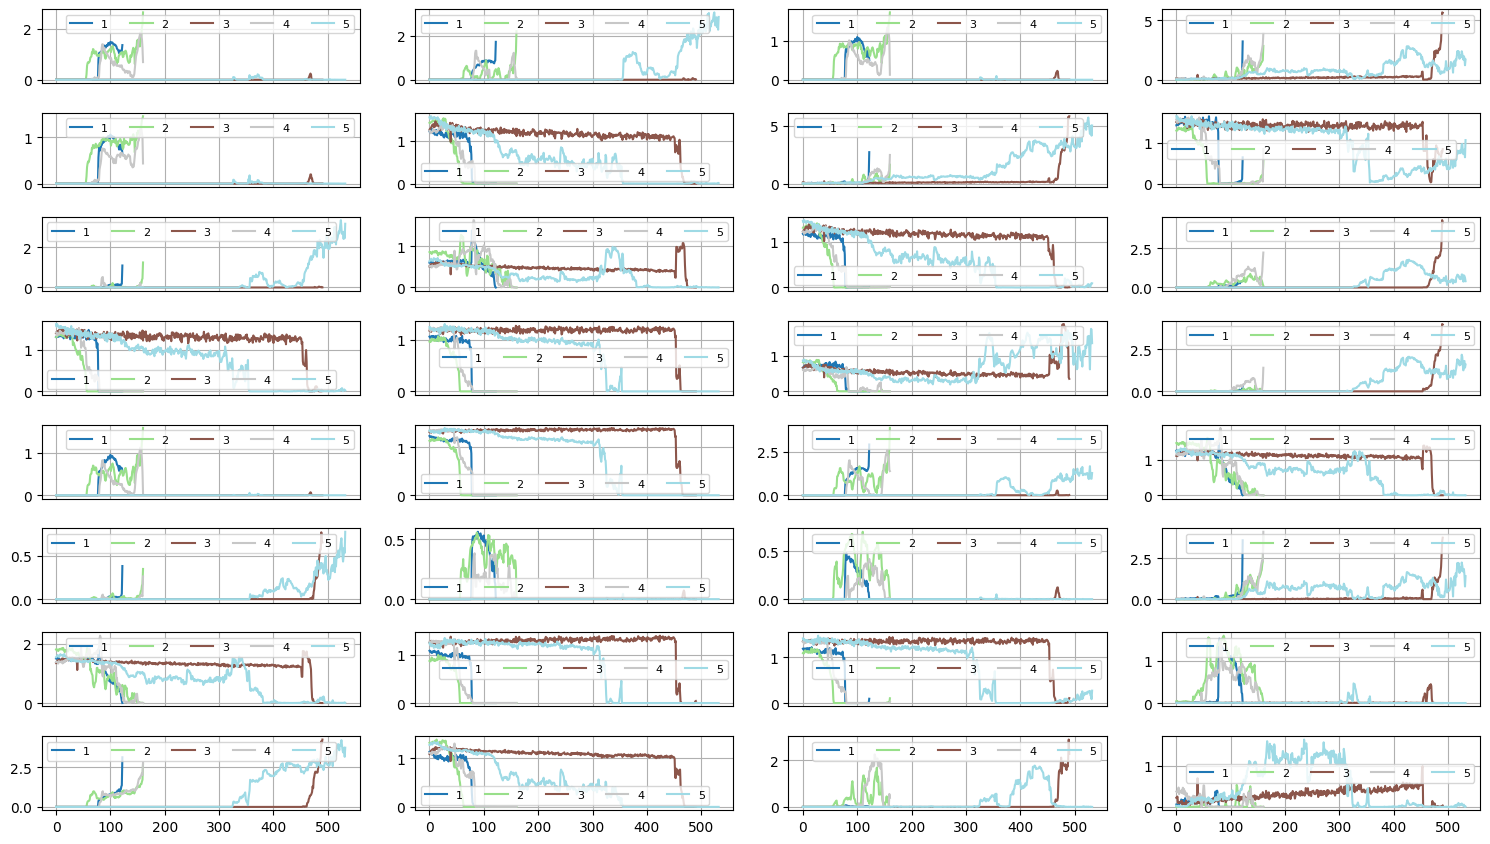

In [55]:
path = r'Dataset\XJTU\DSI3'
brngs = ['B11.csv','B12.csv','B21.csv','B22.csv','B23.csv'][:]
dataframes = [(pd.read_csv(os.path.join(path,brng))) for brng in brngs]
#dataframes = [normalize_df(df) for df in dataframes]
#dataframes = [exponential_moving_average_df(df,alpha=0.15) for df in dataframes]
PlotDataframes(dataframes,w=15,h=9)

In [22]:
path = r'Dataset\XJTU\DSI3\B11.csv'
df = pd.read_csv(path)
df

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10,...,F23,F24,F25,F26,F27,F28,F29,F30,F31,F32
0,0.000000,0.049149,1.447902,0.000767,0.000700,0.559786,0.781664,0.426605,0.000000,0.000000,...,0.000000,0.000000,0.223441,0.000000,0.733858,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,0.041229,1.429161,0.000821,0.000651,0.562809,0.783873,0.423263,0.000000,0.000000,...,0.000000,0.000000,0.222007,0.000000,0.724043,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.000000,0.047045,1.443020,0.000818,0.000691,0.564061,0.787575,0.420907,0.000000,0.000000,...,0.000000,0.000000,0.214711,0.000000,0.725918,0.000000,0.000000,0.000000,0.000000,0.000000
3,0.000000,0.051403,1.447575,0.000778,0.000560,0.564710,0.786595,0.422962,0.000000,0.000000,...,0.000000,0.000000,0.212344,0.000000,0.728763,0.000000,0.000000,0.000000,0.000000,0.000000
4,0.000000,0.049960,1.442574,0.000773,0.000690,0.564489,0.785829,0.418918,0.000000,0.000000,...,0.000000,0.000000,0.210062,0.000000,0.726480,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,0.087377,0.631527,0.000000,0.001573,0.099964,0.000000,0.173561,0.052152,1.862993,0.398390,...,1.055236,0.001431,0.000000,0.001449,0.304548,0.000002,0.000512,0.004030,0.664787,0.021457
119,0.131906,0.795731,0.000000,0.004523,0.104907,0.000017,0.162895,0.020852,2.085965,0.421165,...,1.040052,0.000000,0.000000,0.001915,0.364359,0.000000,0.001072,0.003638,0.743255,0.013077
120,0.164913,0.977332,0.000000,0.009876,0.158816,0.000000,0.115178,0.026482,2.320938,0.370168,...,1.113992,0.000905,0.000000,0.001625,0.407683,0.000000,0.000000,0.002955,0.873686,0.015717
121,0.273866,1.274569,0.000000,0.043747,0.197379,0.000000,0.085885,0.011327,2.722405,0.380617,...,1.140059,0.001318,0.000000,0.001523,0.532770,0.001112,0.000465,0.004027,1.030793,0.011683
